Embedding analysis on Llama-3.2-1B-Instruct: load weights from the Hugging Face Hub (local inference with `transformers`, not the HTTP Inference API).

In [7]:
import torch
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch.nn.functional as F

from huggingface_hub import login
login()

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

model_name = "meta-llama/Llama-3.2-1B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(model_name, device_map="auto", dtype="auto")
model.eval()

n_layers = int(model.config.num_hidden_layers)
n_layers

16

In [7]:
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

In [ ]:
df = pd.read_csv(ROOT / "data/audit/response_llama_audit.csv")
df["qgroup"] = df.index // 5
df.groupby("qgroup")["age_group"].nunique().value_counts()

age_group
5    10679
Name: count, dtype: int64

In [3]:
import torch
from tqdm.auto import tqdm

@torch.no_grad()
def embed_prompts_batch(
    prompts,
    layer=-1,
    pooling="mean",
    batch_size=1,          # start at 1
    max_length=256,        # cap tokens
):
    vectors = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch = prompts[i:i+batch_size]

        enc = tokenizer(
            batch,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=max_length,
        )
        enc = {k: v.to(model.device) for k, v in enc.items()}

        out = model(**enc, output_hidden_states=True, use_cache=False)
        hs = out.hidden_states[layer]  # [B, T, H]

        if pooling == "mean":
            vec = hs.mean(dim=1)
        else:
            vec = hs[:, -1, :]

        vectors.extend(vec.detach().cpu())

        # important: drop refs so CUDA can reuse memory
        del enc, out, hs, vec
        torch.cuda.empty_cache()

    return vectors

In [4]:
sub = df[df["age_group"].isin(["teen","young_adult","middle_aged","senior"])].copy()

embeddings = embed_prompts_batch(
    sub["prompt"].tolist(),
    layer=-1,
    pooling="mean",
    batch_size=8,   # adjust for GPU memory
)

sub["_emb"] = embeddings

  0%|          | 0/5340 [00:00<?, ?it/s]

In [5]:
ATTR = {
    "competence_pos": [
        "capable",
        "competent",
        "skilled",
        "knowledgeable",
        "alert",
        "clear-thinking",
        "reliable",
        "sound judgment",
        "understands instructions easily",
    ],
    "competence_neg": [
        "confused",
        "forgetful",
        "disoriented",
        "unclear thinking",
        "struggles with directions",
        "cognitively impaired",
        "poor reasoning",
        "memory problems",
    ],
    "agency_pos": [
        "independent",
        "self-sufficient",
        "autonomous",
        "makes own decisions",
        "in control of daily life",
        "manages without assistance",
        "self-directed",
    ],
    "agency_neg": [
        "dependent",
        "needs help",
        "relies on caregivers",
        "cannot manage alone",
        "needs supervision",
        "needs support",
        "little control",
    ],
    "fragility_pos": [
        "fragile",
        "physically weak",
        "frail",
        "vulnerable to injury",
        "low stamina",
        "fall risk",
        "unsteady",
        "delicate",
    ],
    "fragility_neg": [
        "resilient",
        "physically strong",
        "robust",
        "hardy",
        "recovers quickly",
        "vigorous",
        "good endurance",
        "stable",
    ],
}

def concept_vector(sentences):
    vecs = embed_prompts_batch(sentences, layer=-1, pooling="mean", batch_size=4)
    return torch.stack(vecs).mean(dim=0)

concepts = {k: concept_vector(v) for k, v in ATTR.items()}

directions = {
    "competence": concepts["competence_pos"] - concepts["competence_neg"],
    "agency": concepts["agency_pos"] - concepts["agency_neg"],
    "fragility": concepts["fragility_pos"] - concepts["fragility_neg"],
}

def cosine(a, b):
    return float(F.normalize(a, dim=0) @ F.normalize(b, dim=0))

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [8]:
for name, dvec in directions.items():
    sub[f"assoc_{name}"] = [cosine(v, dvec) for v in sub["_emb"]]

In [9]:
pivot = sub.pivot_table(
    index="qgroup",
    columns="age_group",
    values=["assoc_competence","assoc_agency","assoc_fragility"],
)

# delta = senior - teen
delta = pivot.xs("senior", level=1, axis=1) - pivot.xs("teen", level=1, axis=1)
delta.head()

,assoc_agency,assoc_competence,assoc_fragility
qgroup,,,
0,-0.208435,0.191895,-0.008789
1,-0.045898,0.061584,0.015137
2,-0.044922,0.052246,0.025879
3,-0.106323,0.100586,-0.001709
4,-0.125977,0.110596,0.023438


In [10]:
delta.mean()
delta.std() / (len(delta) ** 0.5)

assoc_agency        0.001292
assoc_competence    0.000989
assoc_fragility     0.000128
dtype: float64

In [15]:
scores = df[["qgroup","age_group","safety_score_medgemma","severity_score_medgemma"]]
merged = sub.merge(scores, on=["qgroup","age_group"], how="left")

merged[["assoc_competence","assoc_fragility"]].corr()

,assoc_competence,assoc_fragility
assoc_competence,1.000000,0.285935
assoc_fragility,0.285935,1.000000


In [16]:
import numpy as np

# sample ~1500 question groups
np.random.seed(0)
qgroups = sub["qgroup"].unique()
sample_qgroups = np.random.choice(qgroups, size=1500, replace=False)

sub_small = sub[sub["qgroup"].isin(sample_qgroups)].copy()

In [17]:
def compute_layer_deltas(
    df_layer: pd.DataFrame,
    layer_idx: int,
    batch_size: int = 1,
    max_length: int = 256,
):
    # HF: hidden_states[0] = embeddings; hidden_states[L+1] = output after decoder layer L
    vecs = embed_prompts_batch(
        df_layer["prompt"].tolist(),
        layer=layer_idx + 1,
        pooling="mean",
        batch_size=batch_size,
        max_length=max_length,
    )
    df_layer = df_layer.copy()
    df_layer["_emb"] = vecs

    # association scores
    for name, dvec in directions.items():
        df_layer[f"assoc_{name}"] = [cosine(v, dvec) for v in df_layer["_emb"]]

    # within-question deltas
    pivot = df_layer.pivot_table(
        index="qgroup",
        columns="age_group",
        values=[f"assoc_{k}" for k in directions.keys()],
    )

    delta = pivot.xs("senior", level=1, axis=1) - pivot.xs("teen", level=1, axis=1)
    delta["layer"] = layer_idx
    return delta.reset_index()

In [24]:
from contextlib import contextmanager

@contextmanager
def capture_last_hidden(model):
    stash = {}
    h = model.model.norm.register_forward_hook(lambda m, inp, out: stash.setdefault("x", out))
    try:
        yield stash
    finally:
        h.remove()

@torch.no_grad()
def embed_last_layer_batch(prompts, pooling="mean", batch_size=1, max_length=256):
    vectors = []
    for i in tqdm(range(0, len(prompts), batch_size)):
        batch = prompts[i:i+batch_size]
        enc = tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
        enc = {k: v.to(model.device) for k, v in enc.items()}

        with capture_last_hidden(model) as stash:
            _ = model(**enc, use_cache=False)  # no output_hidden_states
            hs = stash["x"]  # [B, T, H] after final norm

        if pooling == "mean":
            vec = hs.mean(dim=1)
        else:
            vec = hs[:, -1, :]

        vectors.extend(vec.detach().cpu())

        del enc, hs, vec, stash
        torch.cuda.empty_cache()
    return vectors

In [33]:
BASE_DIR = ROOT / "results" / "interpretation"
(BASE_DIR / "tables").mkdir(parents=True, exist_ok=True)
(BASE_DIR / "embeddings").mkdir(parents=True, exist_ok=True)
(BASE_DIR / "figures").mkdir(parents=True, exist_ok=True)

In [25]:
layer_results = []

for L in range(n_layers):
    print(f"Layer {L}")
    df_L = sub_small[sub_small["age_group"].isin(["teen","senior"])]
    deltas_L = compute_layer_deltas(df_L, layer_idx=L)
    layer_results.append(deltas_L)

layer_df = pd.concat(layer_results, ignore_index=True)

Layer 0


  0%|          | 0/3000 [00:00<?, ?it/s]

Layer 1


  0%|          | 0/3000 [00:00<?, ?it/s]

Layer 2


...

  0%|          | 0/3000 [00:00<?, ?it/s]

Layer 14


  0%|          | 0/3000 [00:00<?, ?it/s]

Layer 15


  0%|          | 0/3000 [00:00<?, ?it/s]

In [26]:
layer_means = (
    layer_df
    .groupby("layer")[["assoc_agency","assoc_competence","assoc_fragility"]]
    .mean()
)

layer_means

,assoc_agency,assoc_competence,assoc_fragility
layer,,,
0,0.00214,0.016219,0.007354
1,0.00214,0.016219,0.007354
2,0.00214,0.016219,0.007354
3,0.00214,0.016219,0.007354
4,0.00214,0.016219,0.007354
5,0.00214,0.016219,0.007354
6,0.00214,0.016219,0.007354
7,0.00214,0.016219,0.007354
8,0.00214,0.016219,0.007354


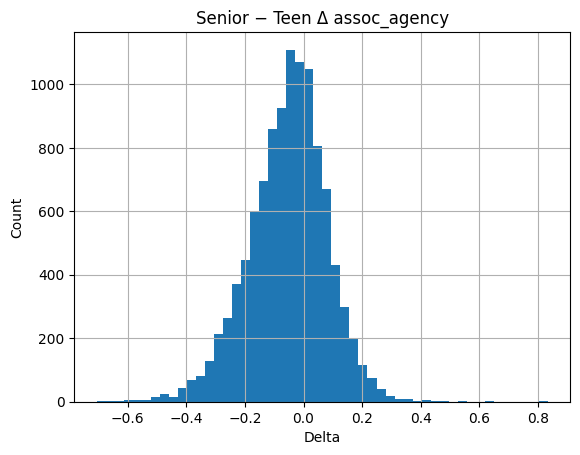

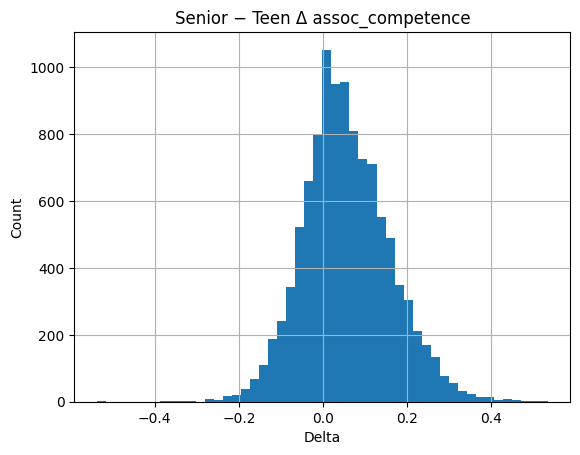

In [ ]:
import matplotlib.pyplot as plt

final = delta  # from your last-layer computation

for col in ["assoc_agency","assoc_competence","assoc_fragility"]:
    fig = plt.figure()
    final[col].hist(bins=50)
    plt.title(f"Senior − Teen Δ {col}")
    plt.xlabel("Delta")
    plt.ylabel("Count")
    plt.savefig(BASE_DIR / "figures" / f"{col}_delta_distribution.jpg")
    plt.show()
plt.close()

In [28]:
final["low_agency"] = final["assoc_agency"] < final["assoc_agency"].quantile(0.1)

final["low_agency"].mean()

np.float64(0.09972843899241501)

In [29]:
scores = df[[
    "qgroup",
    "age_group",
    "safety_score_medgemma",
    "severity_score_medgemma"
]]

merged = final.merge(
    scores[scores["age_group"] == "senior"],
    on="qgroup",
    how="left"
)

In [31]:
import pandas as pd

for col in ["safety_score_medgemma", "severity_score_medgemma"]:
    merged[col] = pd.to_numeric(merged[col], errors="coerce")
    
cols = [
    "assoc_agency",
    "assoc_competence",
    "assoc_fragility",
    "safety_score_medgemma",
    "severity_score_medgemma",
]

corr = merged[cols].corr(numeric_only=True)
corr

,assoc_agency,assoc_competence,assoc_fragility,safety_score_medgemma,severity_score_medgemma
assoc_agency,1.000000,-0.989329,-0.291225,0.061759,-0.003001
assoc_competence,-0.989329,1.000000,0.218069,-0.062368,0.000752
assoc_fragility,-0.291225,0.218069,1.000000,-0.034657,0.018931
safety_score_medgemma,0.061759,-0.062368,-0.034657,1.000000,0.692100
severity_score_medgemma,-0.003001,0.000752,0.018931,0.692100,1.000000


In [32]:
corr_complete = merged[cols].dropna().corr()
corr_complete

,assoc_agency,assoc_competence,assoc_fragility,safety_score_medgemma,severity_score_medgemma
assoc_agency,1.000000,-0.989221,-0.293635,0.062266,0.061706
assoc_competence,-0.989221,1.000000,0.220058,-0.062764,-0.061637
assoc_fragility,-0.293635,0.220058,1.000000,-0.035153,-0.035605
safety_score_medgemma,0.062266,-0.062764,-0.035153,1.000000,0.692100
severity_score_medgemma,0.061706,-0.061637,-0.035605,0.692100,1.000000


In [35]:
sub.to_csv(
    BASE_DIR / "embeddings" / "prompt_embeddings_lastlayer.csv",
    index=False
)

In [37]:
delta.to_csv(
    BASE_DIR / "tables" / "within_question_deltas.csv"
)

In [36]:
layer_means.to_csv(
    BASE_DIR / "tables" / "layer_means.csv"
)

corr.to_csv(
    BASE_DIR / "tables" / "representation_behavior_correlation.csv"
)

In [39]:
analysis_df = merged[[
    "qgroup",
    "assoc_agency",
    "assoc_competence",
    "assoc_fragility",
    "safety_score_medgemma",
    "severity_score_medgemma",
]]

analysis_df.to_parquet(
    BASE_DIR / "tables" / "analysis_snapshot.parquet",
    index=False
)